# Supplemental: Advanced Visualization in Python

**CS1090A / AC209A — Module 1** *(optional enrichment)*

The visualization lecture gave you principles and a map of the ecosystem; the
Matplotlib & Seaborn reference gave you the core syntax. This notebook covers the
techniques one level up — the ones that separate a plot that *answers a question*
from a plot that merely *shows data*:

1. **Faceting** (small multiples) — comparison via repetition
2. **Pairwise overviews** — seeing a whole dataset at once
3. **Heatmaps** — when both axes are categories
4. **Annotation** — guiding the reader's eye
5. **Interactivity** — what it buys, and when it's the wrong tool

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
penguins = sns.load_dataset("penguins").dropna()
flights = sns.load_dataset("flights")
tips = sns.load_dataset("tips")

## 1. Faceting: small multiples

When a third variable makes one plot too crowded, don't cram — **repeat the plot
once per category** with shared axes. Edward Tufte called these *small multiples*;
they work because the reader learns the layout once and then only sees what
changes.

Seaborn's *figure-level* functions (`relplot`, `catplot`, `displot`) build the
grid for you via `col=`/`row=`.

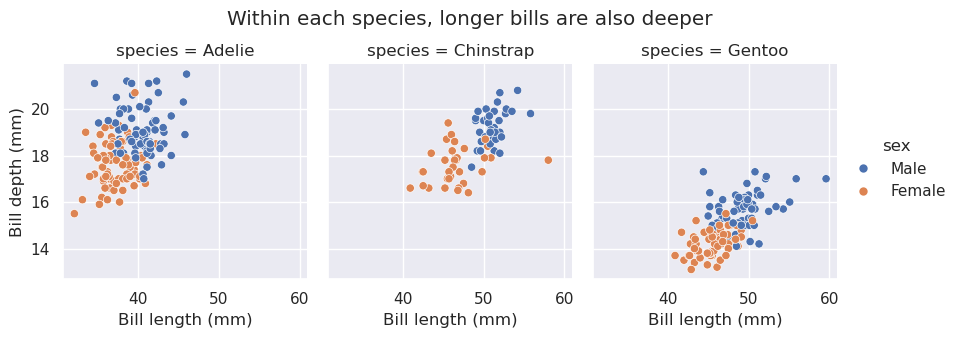

In [2]:
g = sns.relplot(
    data=penguins, x="bill_length_mm", y="bill_depth_mm",
    hue="sex", col="species",
    height=3.2, aspect=0.9,
)
g.set_axis_labels("Bill length (mm)", "Bill depth (mm)")
g.figure.suptitle("Within each species, longer bills are also deeper", y=1.05)
plt.show()

Note the *finding* stated in the title. Compare this to a single scatter of all
three species mixed together, where the **overall** length–depth trend actually
reverses (this is Simpson's paradox — faceting is one honest way out of it).

When you need faceting around a plot seaborn doesn't provide, drop down to
`FacetGrid` and `.map_dataframe(...)` — same idea, any plotting function.

## 2. Pairwise overview: `pairplot`

Early in EDA, before you know *which* relationship matters, look at all of them.
One line buys every pairwise scatter plus per-variable distributions.

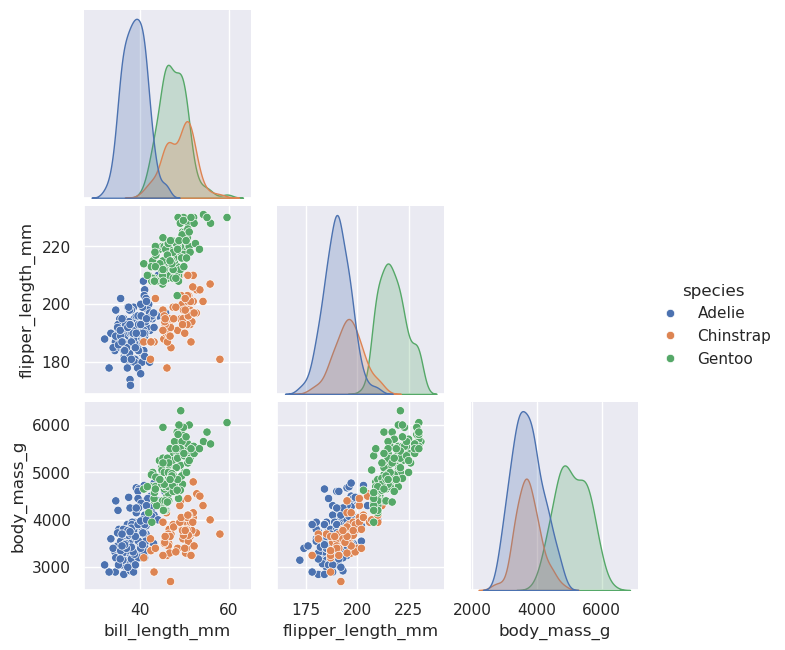

In [3]:
sns.pairplot(penguins, vars=["bill_length_mm", "flipper_length_mm", "body_mass_g"],
             hue="species", corner=True, height=2.2)
plt.show()

`corner=True` drops the redundant upper triangle — less ink, same information.
Pairplots are **exploration** tools: use them to find the story, then make a
focused plot to *tell* it. (A pairplot dropped into a report unexplained usually
means the author stopped at exploration.)

## 3. Heatmaps: when both axes are categorical

Reshape to a wide table with `pivot_table`, then map values to color. The classic
example: flights per month × year.

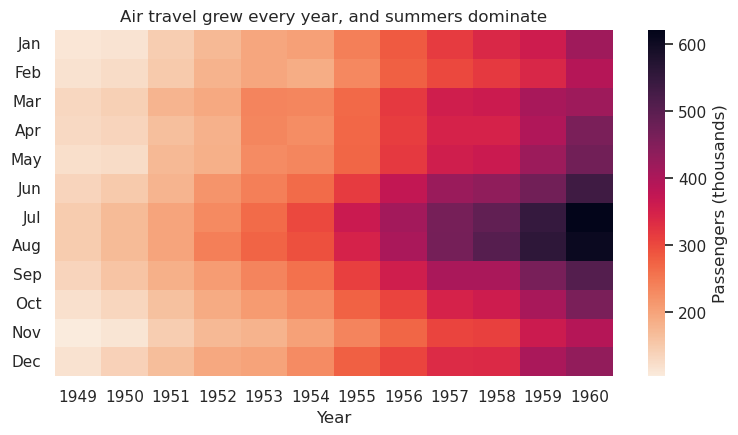

In [4]:
flights_wide = flights.pivot_table(values="passengers", index="month",
                                   columns="year", observed=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(flights_wide, cmap="rocket_r", ax=ax,
            cbar_kws={"label": "Passengers (thousands)"})
ax.set_title("Air travel grew every year, and summers dominate")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.show()

Two craft points: pick a **sequential** colormap for quantities (`rocket_r`,
`viridis` — not rainbow), and label the colorbar — it's an axis too. For a small
grid, `annot=True` prints the numbers in the cells and can replace the colorbar
entirely.

## 4. Annotation: guide the reader's eye

A finished plot doesn't just display data — it points at the part that matters.
Three moves worth knowing: **direct labels** on the data (often better than a
legend), `ax.annotate` with an arrow for the interesting point, and muted color
for context vs. saturated color for the subject.

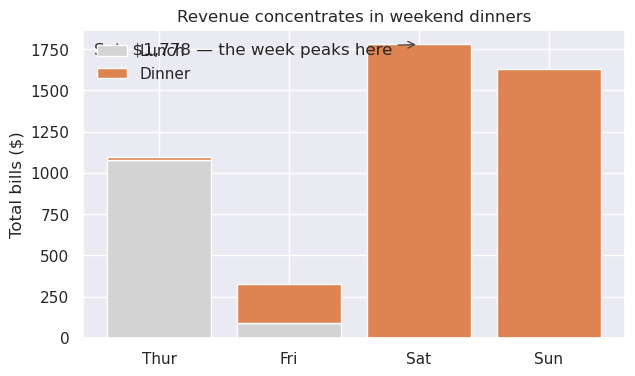

In [5]:
# Highlight one theater-week story: emphasize Saturday dinner in context
daily = tips.groupby(["day", "time"], observed=True)["total_bill"].sum().unstack()

fig, ax = plt.subplots(figsize=(7, 4))
days = daily.index.astype(str)

# context: lunch in muted gray; subject: dinner in color
ax.bar(days, daily["Lunch"], color="lightgray", label="Lunch")
ax.bar(days, daily["Dinner"], bottom=daily["Lunch"].fillna(0),
       color="C1", label="Dinner")

# direct annotation of the takeaway
peak_day = daily.sum(axis=1).idxmax()
peak_val = daily.sum(axis=1).max()
ax.annotate(
    f"{peak_day}: ${peak_val:,.0f} — the week peaks here",
    xy=(list(days).index(str(peak_day)), peak_val),
    xytext=(0.02, 0.92), textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="0.3"),
)

ax.set_ylabel("Total bills ($)")
ax.set_title("Revenue concentrates in weekend dinners")
ax.legend(frameon=False)
plt.show()

## 5. Interactivity: what it buys — and when to skip it

Static plots are for **communication** (reports, homework, papers): the author
chooses the message. Interactive plots are for **exploration** (dashboards,
debugging data): the *reader* chooses. Tooltips, zooming, and toggling series are
wonderful when the audience needs to interrogate the data — and a distraction
when they need to receive a conclusion.

The two most common libraries:

- **[Plotly Express](https://plotly.com/python/plotly-express/)** — one-liner
  interactive charts with hover tooltips; seaborn-like API.
- **[Altair / Vega-Lite](https://altair-viz.github.io/)** — declarative *grammar
  of graphics*; interactions (brushing, linking) are specified, not programmed.

Neither ships with the course environment; the cell below runs if you have
plotly installed and politely tells you how to get it if not.

plotly not installed — `pip install plotly` (or add it to your env)
The same figure in seaborn, minus the tooltips:


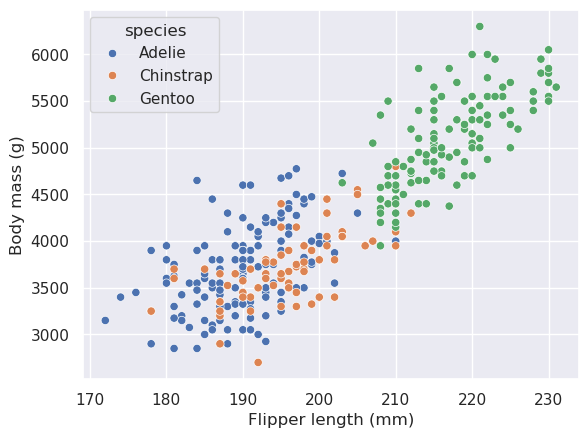

In [6]:
try:
    import plotly.express as px
    fig = px.scatter(
        penguins, x="flipper_length_mm", y="body_mass_g",
        color="species", hover_data=["island", "sex"],
        labels={"flipper_length_mm": "Flipper length (mm)",
                "body_mass_g": "Body mass (g)"},
        title="Hover any point for its full record",
    )
    fig.show()
except ImportError:
    print("plotly not installed — `uv pip install plotly` inside your section env")
    print("The same figure in seaborn, minus the tooltips:")
    ax = sns.scatterplot(data=penguins, x="flipper_length_mm",
                         y="body_mass_g", hue="species")
    ax.set_xlabel("Flipper length (mm)"); ax.set_ylabel("Body mass (g)")
    plt.show()

For HW1: static matplotlib/seaborn is the right call — your notebook is a
*report*, graders read it linearly, and interactive figures don't survive
PDF/print rendering. Save interactivity for your own exploration.

## 6. The ecosystem, one table

| Library | Paradigm | Reach for it when |
|---|---|---|
| **Matplotlib** | imperative, draws anything | full control; publication figures; the substrate everything else builds on |
| **Seaborn** | statistical, DataFrame-native | EDA on tidy data; distributions, facets |
| **pandas `.plot`** | convenience wrapper | one-line looks mid-analysis |
| **Plotly** | interactive, JS-rendered | dashboards, hover-to-inspect |
| **Altair** | declarative grammar | linked/brushed interactions, web-native |
| **Bokeh / HoloViews** | interactive, server-capable | streaming/big-data apps |

They all consume DataFrames — the skills that transfer are *tidy data* and the
*principles* from lecture, not any one library's syntax.

**Exercises:**
1. Take your HW1 Q5 "year distribution by theater" plot and rebuild it as a
   faceted `displot(col='theater')`. Which version communicates better, and why?
2. Rebuild the §3 heatmap with `annot=True, fmt='.0f'` and no colorbar. At what
   grid size does annotation stop working?
3. Add an `ax.annotate` call to your favorite HW1 plot that points at the single
   most interesting data point and says why it's interesting.